In [11]:
import itertools

tasks = [0, 4, 12, 14, 15]
maps = ["none", "ast", "ast_compact"]
reps = range(0, 5)

expected = set(itertools.product(tasks, maps, reps))

import os
os.chdir('/mnt/c/Users/afbla/Documents/Imperial/final_project')
existing = set()
for fname in os.listdir("results/mistral_devstral-medium-latest"):
    if "_rep" in fname:
        parts = fname.replace(".json", "").split("_")
        # filename pattern: task_{idx}_{map}_rep{n}
        try:
            idx = int(parts[1])
            rep = int(parts[-1].replace("rep", ""))
            map_type = "_".join(parts[2:-1])
            existing.add((idx, map_type, rep))
        except (ValueError, IndexError):
            continue

missing = expected - existing
print(f"Missing {len(missing)} combinations:")
for combo in sorted(missing):
    print(combo)

Missing 0 combinations:


In [13]:
tasks = [0, 4, 12, 14, 15]
maps = ["none", "ast", "ast_compact"]
reps = range(0, 5)

expected = set(itertools.product(tasks, maps, reps))

existing = set()
for fname in os.listdir("results/mistral_devstral-small-latest"):
    if "_rep" in fname:
        parts = fname.replace(".json", "").split("_")
        try:
            idx = int(parts[1])
            rep = int(parts[-1].replace("rep", ""))
            map_type = "_".join(parts[2:-1])
            existing.add((idx, map_type, rep))
        except (ValueError, IndexError):
            continue

missing = expected - existing
print(f"Missing {len(missing)} combinations:")
for combo in sorted(missing):
    print(combo)

Missing 0 combinations:


In [33]:
import json
import os
import pandas as pd

def load_results(folder, batch_label):
    rows = []
    for fname in os.listdir(folder):
        if not fname.endswith(".json"):
            continue
        with open(os.path.join(folder, fname)) as f:
            data = json.load(f)
        rows.append({
            "batch": batch_label,
            "requested_model": data.get("model"),
            "task_idx": data.get("task_idx"),
            "map_type": data.get("map_type"),
            "rep": data.get("rep"),
            "input_tokens": data["metrics"]["total_input_tokens"],
            "output_tokens": data["metrics"]["total_output_tokens"],
            "cost": data["metrics"]["total_cost"],
            "turns": data["metrics"]["num_turns"],
            "wall_time": data["metrics"]["wall_time_seconds"],
            "stop_reason": data["metrics"]["stop_reason"],
            "precision": data["scores"]["precision"],
            "recall": data["scores"]["recall"],
            "f1": data["scores"]["f1"],
        })
    return rows

rows = []
rows += load_results("results/mistral_devstral-medium-latest/", "batch1_medium")
rows += load_results("results/mistral_devstral-small-latest/", "batch2_small_label")

df = pd.DataFrame(rows)
df["model"] = "devstral-medium-2512"  # both batches actually ran this model

print(f"Total combined trials: {len(df)}")
print(df["batch"].value_counts())
print()

# --- Step 1: check whether the two batches behave similarly before pooling ---
print("=== Mean metrics by batch ===")
print(df.groupby("batch")[["f1", "precision", "recall", "turns", "cost", "wall_time", "input_tokens"]].mean())
print()

print("=== Std dev by batch ===")
print(df.groupby("batch")[["f1", "turns", "cost", "wall_time"]].std())
print()

# --- Optional: formal check using a t-test on f1 between batches ---
from scipy import stats

batch1_f1 = df[df["batch"] == "batch1_medium"]["f1"]
batch2_f1 = df[df["batch"] == "batch2_small_label"]["f1"]

t_stat, p_value = stats.ttest_ind(batch1_f1, batch2_f1, equal_var=False)
print(f"=== F1 t-test between batches ===")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")
print("(p > 0.05 suggests no significant difference -- safe to pool)")
print()

# --- Step 2: if batches look consistent, save the pooled dataset ---
df.to_csv("results_summary_devstral_medium_pooled.csv", index=False)
print(f"Saved pooled dataset: {df.shape}")

Total combined trials: 150
batch
batch1_medium         75
batch2_small_label    75
Name: count, dtype: int64

=== Mean metrics by batch ===
                          f1  precision    recall      turns      cost  \
batch                                                                    
batch1_medium       0.739560   0.806667  0.717779  13.560000  0.034440   
batch2_small_label  0.737781   0.793333  0.722223  13.733333  0.028677   

                    wall_time   input_tokens  
batch                                         
batch1_medium       80.893733  174228.533333  
batch2_small_label  36.976000  170479.386667  

=== Std dev by batch ===
                          f1     turns      cost  wall_time
batch                                                      
batch1_medium       0.372423  5.640682  0.024839  51.136736
batch2_small_label  0.384353  5.184002  0.021425  15.096996

=== F1 t-test between batches ===
t-statistic: 0.0288, p-value: 0.9771
(p > 0.05 suggests no significant dif

In [34]:
import pandas as pd

df = pd.read_csv("results_summary_devstral_medium_pooled.csv")

print(f"Total pooled trials: {len(df)}\n")

# --- Overall pooled means (ignoring batch split, ignoring map/task split) ---
print("=== Overall pooled metrics (all 150 trials) ===")
print(df[["f1", "precision", "recall", "turns", "cost", "input_tokens"]].agg(["mean", "std", "count"]))
print()

# --- Pooled, broken down by map_type only ---
print("=== Pooled metrics by map_type ===")
print(df.groupby("map_type")[["f1", "precision", "recall", "turns", "cost", "input_tokens"]].agg(["mean", "std"]))
print()

# --- Pooled, broken down by task ===
print("=== Pooled metrics by task_idx ===")
print(df.groupby("task_idx")[["f1", "precision", "recall", "turns", "cost"]].agg(["mean", "std"]))
print()

# --- Pooled, broken down by task AND map_type (your core comparison table) ---
print("=== Pooled metrics by task_idx x map_type ===")
summary_table = df.groupby(["task_idx", "map_type"])[["f1", "precision", "recall", "turns"]].agg(["mean", "std", "count"])
print(summary_table)
print()

Total pooled trials: 150

=== Overall pooled metrics (all 150 trials) ===
               f1   precision      recall       turns        cost  \
mean     0.738671    0.800000    0.720001   13.646667    0.031558   
std      0.377164    0.388596    0.393043    5.399648    0.023297   
count  150.000000  150.000000  150.000000  150.000000  150.000000   

        input_tokens  
mean   172353.960000  
std    125915.314742  
count     150.000000  

=== Pooled metrics by map_type ===
                   f1           precision              recall            \
                 mean       std      mean       std      mean       std   
map_type                                                                  
ast          0.732670  0.390504      0.80  0.404061  0.696670  0.397969   
ast_compact  0.741336  0.396901      0.79  0.405196  0.723334  0.407707   
none         0.742006  0.349978      0.81  0.362671  0.739998  0.379704   

             turns                cost           input_tokens         

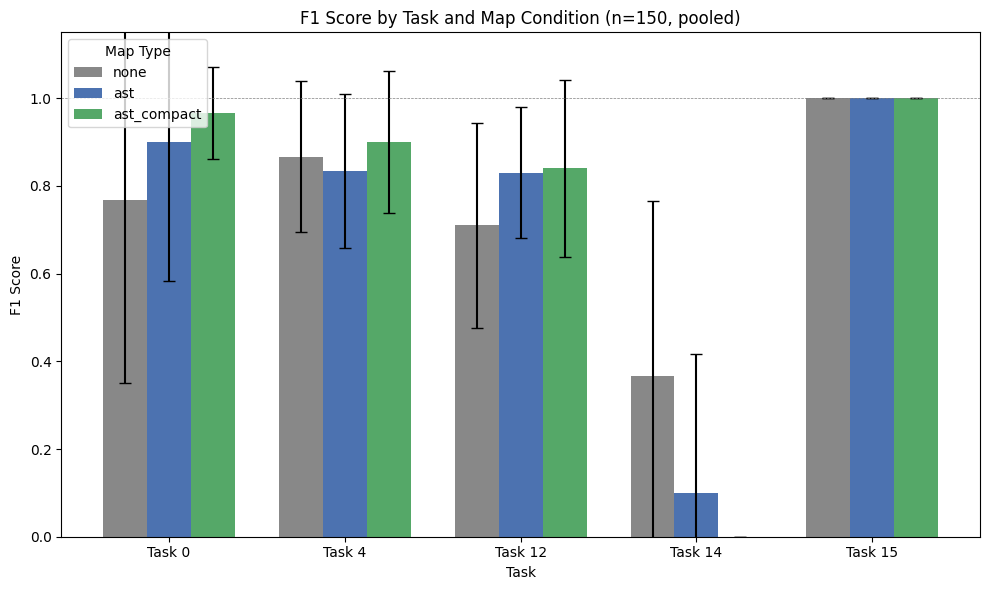

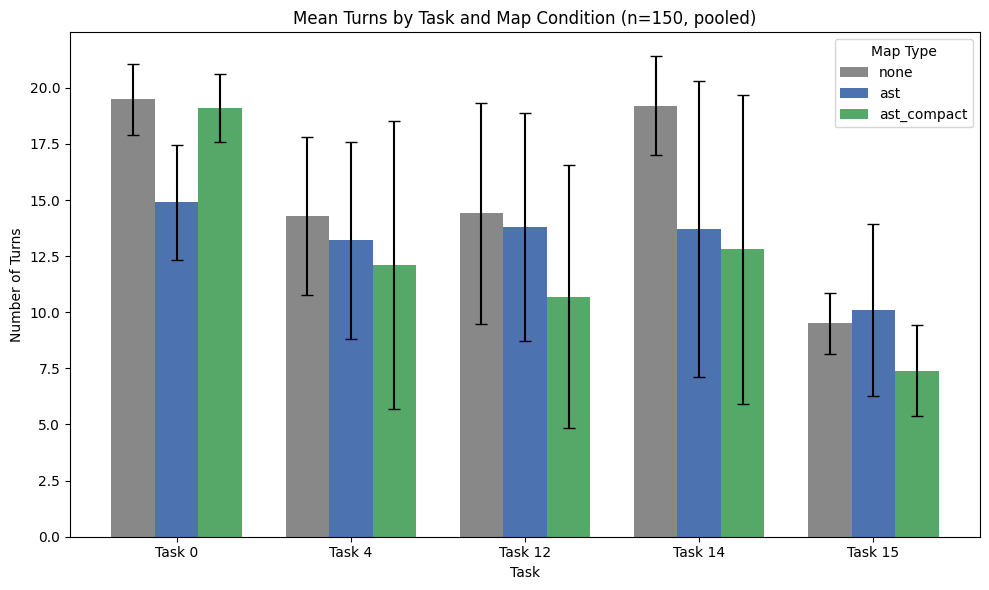

In [36]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results_summary_devstral_medium_pooled.csv")

tasks = sorted(df["task_idx"].unique())
maps = ["none", "ast", "ast_compact"]
colors = {"none": "#888888", "ast": "#4C72B0", "ast_compact": "#55A868"}

# ── Chart 1: F1 by task, grouped by map ──────────────────────────────────
grouped = df.groupby(["task_idx", "map_type"])["f1"].agg(["mean", "std"]).reset_index()

x = np.arange(len(tasks))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, map_type in enumerate(maps):
    means, stds = [], []
    for task in tasks:
        row = grouped[(grouped["task_idx"] == task) & (grouped["map_type"] == map_type)]
        means.append(row["mean"].values[0] if not row.empty else 0)
        stds.append(row["std"].values[0] if not row.empty and not pd.isna(row["std"].values[0]) else 0)
    offset = (i - 1) * width
    ax.bar(x + offset, means, width, yerr=stds, capsize=4, label=map_type, color=colors[map_type])

ax.set_xlabel("Task")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score by Task and Map Condition (n=150, pooled)")
ax.set_xticks(x)
ax.set_xticklabels([f"Task {t}" for t in tasks])
ax.set_ylim(0, 1.15)
ax.legend(title="Map Type")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# ── Chart 2: Turns by task, grouped by map ───────────────────────────────
grouped_turns = df.groupby(["task_idx", "map_type"])["turns"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
for i, map_type in enumerate(maps):
    means, stds = [], []
    for task in tasks:
        row = grouped_turns[(grouped_turns["task_idx"] == task) & (grouped_turns["map_type"] == map_type)]
        means.append(row["mean"].values[0] if not row.empty else 0)
        stds.append(row["std"].values[0] if not row.empty and not pd.isna(row["std"].values[0]) else 0)
    offset = (i - 1) * width
    ax.bar(x + offset, means, width, yerr=stds, capsize=4, label=map_type, color=colors[map_type])

ax.set_xlabel("Task")
ax.set_ylabel("Number of Turns")
ax.set_title("Mean Turns by Task and Map Condition (n=150, pooled)")
ax.set_xticks(x)
ax.set_xticklabels([f"Task {t}" for t in tasks])
ax.legend(title="Map Type")
plt.tight_layout()
plt.show()


=== Mean tokens by task and map ===
    task_idx     map_type  input_tokens  output_tokens
0          0          ast      298520.4         1165.2
1          0  ast_compact      224233.5         1262.7
2          0         none      110188.0          935.1
3          4          ast      236967.6         1084.8
4          4  ast_compact      126596.0          944.9
5          4         none       58644.0          681.8
6         12          ast      273672.0         1183.4
7         12  ast_compact      115611.9         1222.7
8         12         none       91769.1          603.7
9         14          ast      343689.0         1219.0
10        14  ast_compact      186423.3         1466.9
11        14         none      247127.0         1030.6
12        15          ast      186757.5          731.7
13        15  ast_compact       63928.8          563.9
14        15         none       21181.3          619.5

=== Mean cost by task and map ===
    task_idx     map_type      cost
0          0 

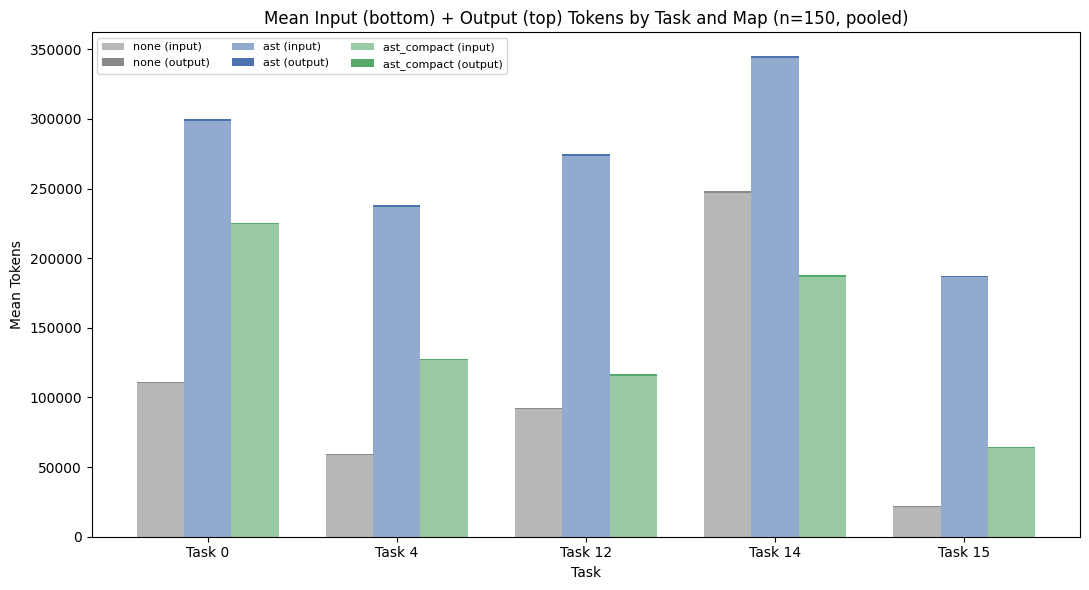

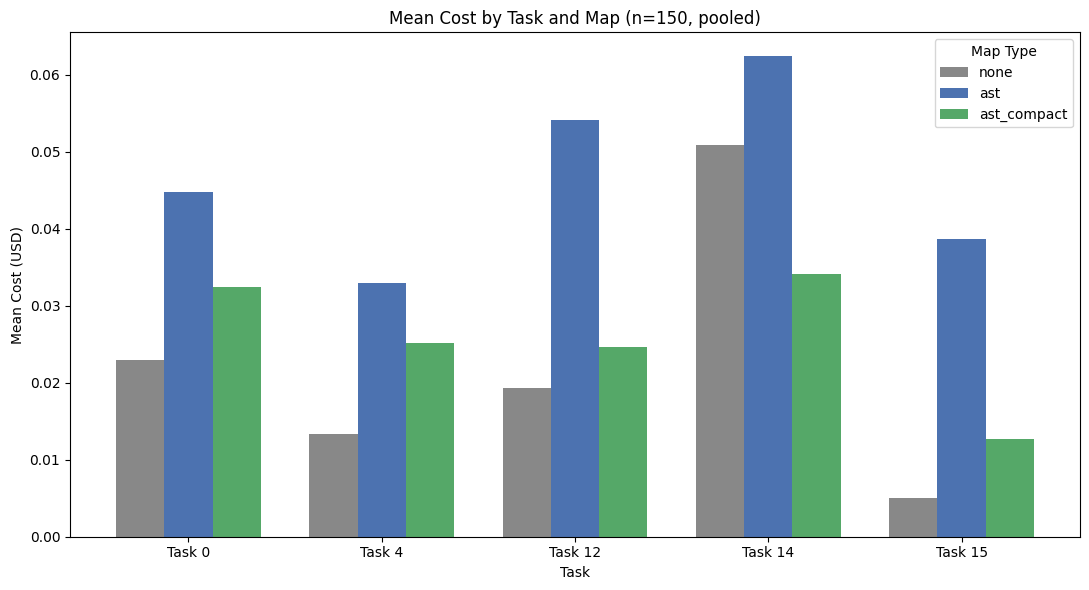

In [37]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results_summary_devstral_medium_pooled.csv")

tasks = sorted(df["task_idx"].unique())
maps = ["none", "ast", "ast_compact"]
map_colors = {"none": "#888888", "ast": "#4C72B0", "ast_compact": "#55A868"}

# ── Tables ────────────────────────────────────────────────────────────────
token_table = df.groupby(["task_idx", "map_type"])[["input_tokens", "output_tokens"]].mean().reset_index()
cost_table = df.groupby(["task_idx", "map_type"])["cost"].mean().reset_index()

print("=== Mean tokens by task and map ===")
print(token_table)
print()
print("=== Mean cost by task and map ===")
print(cost_table)

# ── Chart 1: Stacked input/output TOKENS, grouped by task then map ───────
x = np.arange(len(tasks))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, map_type in enumerate(maps):
    inputs, outputs = [], []
    for task in tasks:
        row = token_table[(token_table["task_idx"] == task) & (token_table["map_type"] == map_type)]
        inputs.append(row["input_tokens"].values[0] if not row.empty else 0)
        outputs.append(row["output_tokens"].values[0] if not row.empty else 0)
    offset = (i - 1) * width
    ax.bar(x + offset, inputs, width, label=f"{map_type} (input)", color=map_colors[map_type], alpha=0.6)
    ax.bar(x + offset, outputs, width, bottom=inputs, label=f"{map_type} (output)", color=map_colors[map_type], alpha=1.0)

ax.set_xlabel("Task")
ax.set_ylabel("Mean Tokens")
ax.set_title("Mean Input (bottom) + Output (top) Tokens by Task and Map (n=150, pooled)")
ax.set_xticks(x)
ax.set_xticklabels([f"Task {t}" for t in tasks])
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

# ── Chart 2: Mean COST, grouped by task then map (cost has no input/output split) ──
fig, ax = plt.subplots(figsize=(11, 6))

for i, map_type in enumerate(maps):
    costs = []
    for task in tasks:
        row = cost_table[(cost_table["task_idx"] == task) & (cost_table["map_type"] == map_type)]
        costs.append(row["cost"].values[0] if not row.empty else 0)
    offset = (i - 1) * width
    ax.bar(x + offset, costs, width, label=map_type, color=map_colors[map_type])

ax.set_xlabel("Task")
ax.set_ylabel("Mean Cost (USD)")
ax.set_title("Mean Cost by Task and Map (n=150, pooled)")
ax.set_xticks(x)
ax.set_xticklabels([f"Task {t}" for t in tasks])
ax.legend(title="Map Type")
plt.tight_layout()
plt.show()

=== Overall stop_reason distribution ===
stop_reason
submitted    107
max_turns     43
Name: count, dtype: int64
stop_reason
submitted    70.0
max_turns    30.0
Name: proportion, dtype: float64 %

=== Stop_reason by map_type ===
stop_reason  max_turns  submitted
map_type                         
ast               20.0       80.0
ast_compact       28.0       72.0
none              38.0       62.0

=== Stop_reason by task_idx ===
stop_reason  max_turns  submitted
task_idx                         
0                 56.7       43.3
4                 16.7       83.3
12                23.3       76.7
14                43.3       56.7
15                 3.3       96.7

=== Mean F1 by stop_reason ===
                 mean       std  count
stop_reason                           
max_turns    0.633337  0.440359     43
submitted    0.781001  0.341782    107



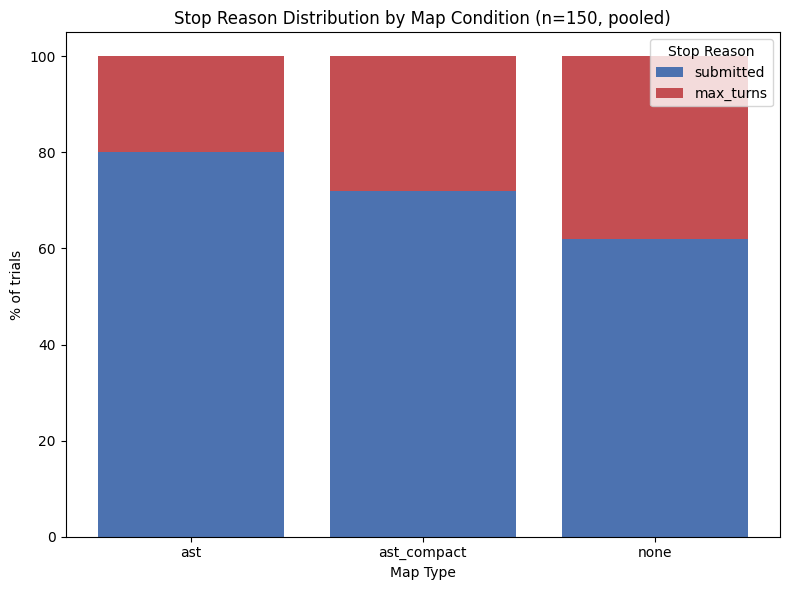

In [38]:
import pandas as pd

df = pd.read_csv("results_summary_devstral_medium_pooled.csv")

# --- Table: stop_reason distribution overall ---
print("=== Overall stop_reason distribution ===")
print(df["stop_reason"].value_counts())
print(df["stop_reason"].value_counts(normalize=True).round(1) * 100, "%")
print()

# --- Table: stop_reason distribution by map_type ---
print("=== Stop_reason by map_type ===")
stop_by_map = pd.crosstab(df["map_type"], df["stop_reason"], normalize="index") * 100
print(stop_by_map.round(1))
print()

# --- Table: stop_reason distribution by task ---
print("=== Stop_reason by task_idx ===")
stop_by_task = pd.crosstab(df["task_idx"], df["stop_reason"], normalize="index") * 100
print(stop_by_task.round(1))
print()

# --- The key comparison: does decisiveness correlate with correctness? ---
print("=== Mean F1 by stop_reason ===")
print(df.groupby("stop_reason")["f1"].agg(["mean", "std", "count"]))
print()

# --- Chart: stacked bar of stop_reason proportions by map_type ---
%matplotlib inline
import matplotlib.pyplot as plt

stop_colors = {"end_turn": "#55A868", "submitted": "#4C72B0", "max_turns": "#C44E52"}
stop_order = ["submitted", "end_turn", "max_turns"]

fig, ax = plt.subplots(figsize=(8, 6))
bottom = pd.Series([0] * len(stop_by_map), index=stop_by_map.index)

for reason in stop_order:
    if reason in stop_by_map.columns:
        ax.bar(stop_by_map.index, stop_by_map[reason], bottom=bottom,
               label=reason, color=stop_colors.get(reason, "#888888"))
        bottom += stop_by_map[reason]

ax.set_ylabel("% of trials")
ax.set_xlabel("Map Type")
ax.set_title("Stop Reason Distribution by Map Condition (n=150, pooled)")
ax.legend(title="Stop Reason")
plt.tight_layout()
plt.show()

In [39]:
import pandas as pd

df = pd.read_csv("results_summary_devstral_medium_pooled.csv")

def cost_per_correct(subset, label):
    n_total = len(subset)
    n_correct = (subset["f1"] == 1.0).sum()
    total_cost = subset["cost"].sum()
    
    cost_per_correct_answer = total_cost / n_correct if n_correct > 0 else float("inf")
    cost_per_trial = total_cost / n_total if n_total > 0 else 0
    accuracy_rate = n_correct / n_total if n_total > 0 else 0
    
    print(f"=== {label} ===")
    print(f"n trials:              {n_total}")
    print(f"n correct (f1==1.0):   {n_correct}")
    print(f"accuracy rate:         {accuracy_rate:.1%}")
    print(f"total cost:            ${total_cost:.4f}")
    print(f"cost per trial:        ${cost_per_trial:.4f}")
    print(f"cost per correct ans:  ${cost_per_correct_answer:.4f}")
    print()
    
    return {
        "label": label,
        "n_total": n_total,
        "n_correct": n_correct,
        "accuracy_rate": accuracy_rate,
        "total_cost": total_cost,
        "cost_per_trial": cost_per_trial,
        "cost_per_correct": cost_per_correct_answer,
    }

results = []
results.append(cost_per_correct(df, "All trials"))
results.append(cost_per_correct(df[df["stop_reason"] == "submitted"], "Voluntarily submitted only"))
results.append(cost_per_correct(df[df["stop_reason"] != "submitted"], "Not voluntarily submitted (end_turn/max_turns)"))

# same breakdown, but split by map_type too
print("\n" + "="*50)
print("BY MAP TYPE")
print("="*50 + "\n")

for map_type in df["map_type"].unique():
    subset_all = df[df["map_type"] == map_type]
    subset_submitted = subset_all[subset_all["stop_reason"] == "submitted"]
    
    results.append(cost_per_correct(subset_all, f"{map_type} -- all trials"))
    results.append(cost_per_correct(subset_submitted, f"{map_type} -- submitted only"))

=== All trials ===
n trials:              150
n correct (f1==1.0):   86
accuracy rate:         57.3%
total cost:            $4.7337
cost per trial:        $0.0316
cost per correct ans:  $0.0550

=== Voluntarily submitted only ===
n trials:              107
n correct (f1==1.0):   65
accuracy rate:         60.7%
total cost:            $2.7178
cost per trial:        $0.0254
cost per correct ans:  $0.0418

=== Not voluntarily submitted (end_turn/max_turns) ===
n trials:              43
n correct (f1==1.0):   21
accuracy rate:         48.8%
total cost:            $2.0159
cost per trial:        $0.0469
cost per correct ans:  $0.0960


BY MAP TYPE

=== ast_compact -- all trials ===
n trials:              50
n correct (f1==1.0):   31
accuracy rate:         62.0%
total cost:            $1.2901
cost per trial:        $0.0258
cost per correct ans:  $0.0416

=== ast_compact -- submitted only ===
n trials:              36
n correct (f1==1.0):   21
accuracy rate:         58.3%
total cost:           

In [40]:
import pandas as pd

df = pd.read_csv("results_summary_devstral_medium_pooled.csv")

def cost_per_correct_weighted(subset, label):
    n_total = len(subset)
    total_cost = subset["cost"].sum()
    
    # weighted "correct answer units" -- sum of F1 scores instead of binary count
    weighted_correct = subset["f1"].sum()
    
    # also keep the strict binary version for comparison
    n_strict_correct = (subset["f1"] == 1.0).sum()
    
    cost_per_weighted_correct = total_cost / weighted_correct if weighted_correct > 0 else float("inf")
    cost_per_strict_correct = total_cost / n_strict_correct if n_strict_correct > 0 else float("inf")
    mean_f1 = subset["f1"].mean()
    
    print(f"=== {label} ===")
    print(f"n trials:                    {n_total}")
    print(f"mean F1:                     {mean_f1:.3f}")
    print(f"weighted correct units:      {weighted_correct:.2f}  (sum of F1 scores)")
    print(f"strict correct count:        {n_strict_correct}  (F1 == 1.0 only)")
    print(f"total cost:                  ${total_cost:.4f}")
    print(f"cost per WEIGHTED correct:   ${cost_per_weighted_correct:.4f}")
    print(f"cost per STRICT correct:     ${cost_per_strict_correct:.4f}")
    print()
    
    return {
        "label": label,
        "n_total": n_total,
        "mean_f1": mean_f1,
        "weighted_correct_units": weighted_correct,
        "strict_correct_count": n_strict_correct,
        "total_cost": total_cost,
        "cost_per_weighted_correct": cost_per_weighted_correct,
        "cost_per_strict_correct": cost_per_strict_correct,
    }

results = []
results.append(cost_per_correct_weighted(df, "All trials"))
results.append(cost_per_correct_weighted(df[df["stop_reason"] == "submitted"], "Voluntarily submitted only"))
results.append(cost_per_correct_weighted(df[df["stop_reason"] != "submitted"], "Not voluntarily submitted"))

print("\n" + "="*50 + "\nBY MAP TYPE\n" + "="*50 + "\n")
for map_type in df["map_type"].unique():
    subset_all = df[df["map_type"] == map_type]
    subset_submitted = subset_all[subset_all["stop_reason"] == "submitted"]
    results.append(cost_per_correct_weighted(subset_all, f"{map_type} -- all trials"))
    results.append(cost_per_correct_weighted(subset_submitted, f"{map_type} -- submitted only"))

summary_df = pd.DataFrame(results)


=== All trials ===
n trials:                    150
mean F1:                     0.739
weighted correct units:      110.80  (sum of F1 scores)
strict correct count:        86  (F1 == 1.0 only)
total cost:                  $4.7337
cost per WEIGHTED correct:   $0.0427
cost per STRICT correct:     $0.0550

=== Voluntarily submitted only ===
n trials:                    107
mean F1:                     0.781
weighted correct units:      83.57  (sum of F1 scores)
strict correct count:        65  (F1 == 1.0 only)
total cost:                  $2.7178
cost per WEIGHTED correct:   $0.0325
cost per STRICT correct:     $0.0418

=== Not voluntarily submitted ===
n trials:                    43
mean F1:                     0.633
weighted correct units:      27.23  (sum of F1 scores)
strict correct count:        21  (F1 == 1.0 only)
total cost:                  $2.0159
cost per WEIGHTED correct:   $0.0740
cost per STRICT correct:     $0.0960


BY MAP TYPE

=== ast_compact -- all trials ===
n trials: